# char_04 — What types of spectra do we actually have?

## Purpose

The previous three notebooks all asked directed questions: what temperature, burned or
unburned, how close to Addis. This one asks nothing and lets the data answer:

> If we cluster every spectrum we hold without telling the algorithm where any of it
> came from, what natural groups appear — and do they correspond to anything we
> recognize?

This is a structure-discovery pass, useful for two reasons. It shows whether the
archive's *nominal* labels (collection, species, temperature) are the same thing as its
*spectral* structure, and it shows whether Addis forms its own type or dissolves into
an existing one.

## Method and its honest limits

Two passes, because there is a real trade-off:

* **Pass A — the charcoal archive alone, 951–3500 cm⁻¹.** All 5,889 spectra with the
  full shared region including the C–O fingerprint. Maximum information, but Addis
  cannot participate.
* **Pass B — everything including Addis, 1430–3500 cm⁻¹.** 6,128 spectra, but blind
  below 1430 where much of the discriminating structure lives.

Clustering is k-means on principal components, with k chosen by silhouette score rather
than asserted. Cluster labels are arbitrary integers — they are named after the fact by
what falls into them, and that naming is a description, not a result.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

from charcoal_spectra import (
    load_all, snv, resample, detrend, prepare, prepare_shape, shape_norm,
    ramp_score, BANDS, CHARCOAL_OVERLAP,
)
from etad_spectra import load_etad

PLOT_DIR = Path("output/plots/char04")
TABLE_DIR = Path("output/tables/char04")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260722
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

# Categorical slots in fixed order; clusters are directly labeled in every figure and
# every figure is backed by a cross-tab, so identity is never carried by color alone.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
          "#4a3aa7", "#e34948"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"
ADDIS_COLOR = "#4a3aa7"

# Preprocessing provenance, stamped on every figure containing Addis (see char_02 §0).
ADDIS_PREP = ("Addis (ETAD): AIRSpec-baselined (APRLssb segmented spline, df1=6) "
              "→ linear detrend → SNV   ·   charcoal: as published → detrend → SNV")


def stamp(fig, text=ADDIS_PREP):
    fig.text(0.5, -0.015, text, ha="center", va="top", fontsize=8, color=INK2)
TEMP_CMAP = plt.get_cmap("Reds")

GRID_A = np.arange(CHARCOAL_OVERLAP[0] + 1, CHARCOAL_OVERLAP[1] - 1 + 1e-9, 2.0)
GRID_B = np.arange(1430.0, 3500.0 + 1e-9, 2.0)

## Build both matrices

In [2]:
sets = load_all()


def stack(grid, include_addis):
    # X is the canonical SNV form the clustering runs on; Xs is the unit-area
    # companion form used only for the archetype-spectrum companion figures.
    X, Xs, meta = [], [], []
    for key, s in sets.items():
        Xr = resample(s.X, s.wn, grid)
        keep = np.isfinite(Xr).all(axis=1)
        det = detrend(Xr[keep], grid)
        X.append(snv(det))
        Xs.append(shape_norm(det, grid))
        m = s.meta.loc[keep].reset_index(drop=True).copy()
        m["source"] = s.short
        m["is_addis"] = False
        meta.append(m)
    if include_addis:
        etad_meta, X_etad, wn_etad = load_etad(baselined=True)
        X.append(prepare(X_etad, wn_etad, grid))
        Xs.append(prepare_shape(X_etad, wn_etad, grid))
        m = pd.DataFrame({
            "source": "Addis (ETAD)", "is_addis": True,
            "species": "ambient PM2.5", "temp_c": np.nan,
            "treatment": etad_meta["season"].to_numpy(),
            "sample": etad_meta["ExternalFilterId"].to_numpy(),
        })
        meta.append(m)
    return np.vstack(X), np.vstack(Xs), pd.concat(meta, ignore_index=True)


XA, XA_shape, metaA = stack(GRID_A, include_addis=False)
XB, XB_shape, metaB = stack(GRID_B, include_addis=True)
print(f"Pass A — charcoal only : {XA.shape[0]:,} spectra × {XA.shape[1]} points "
      f"({GRID_A.min():.0f}–{GRID_A.max():.0f} cm⁻¹)")
print(f"Pass B — with Addis    : {XB.shape[0]:,} spectra × {XB.shape[1]} points "
      f"({GRID_B.min():.0f}–{GRID_B.max():.0f} cm⁻¹)")

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
Pass A — charcoal only : 5,889 spectra × 1274 points (952–3498 cm⁻¹)
Pass B — with Addis    : 6,128 spectra × 1036 points (1430–3500 cm⁻¹)


## How many types are there? Let the silhouette decide.

k-means over k = 2…8 on 10 principal components, scored by silhouette on a fixed random
subsample (silhouette on 6,000 points is expensive and the estimate is stable).

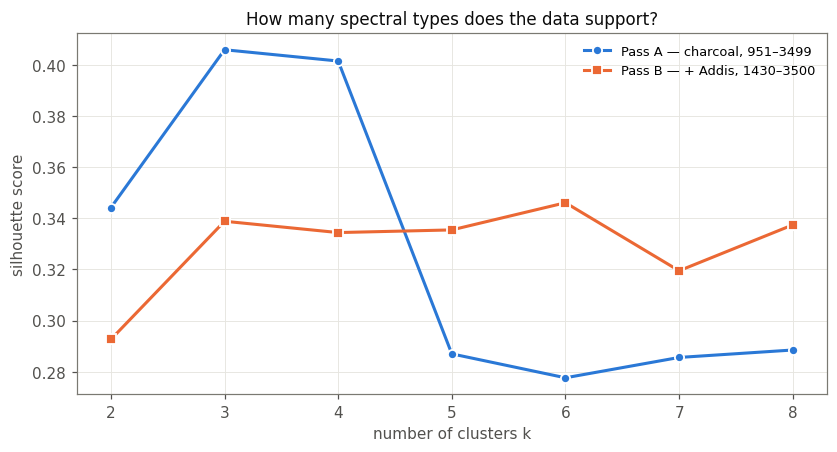

best k — Pass A: 3 (silhouette 0.406)
best k — Pass B: 6 (silhouette 0.346)


pass_,A,B
k,,
2,0.344,0.293
3,0.406,0.339
4,0.401,0.334
5,0.287,0.335
6,0.278,0.346
7,0.286,0.319
8,0.288,0.337


In [3]:
def choose_k(X, ks=range(2, 9), n_pc=10, sample=2500):
    pcs = PCA(n_components=n_pc, random_state=RANDOM_SEED).fit_transform(X)
    idx = rng.choice(len(pcs), min(sample, len(pcs)), replace=False)
    rows = []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit(pcs)
        rows.append({"k": k, "silhouette": silhouette_score(pcs[idx], km.labels_[idx]),
                     "inertia": km.inertia_})
    return pcs, pd.DataFrame(rows)


pcsA, scanA = choose_k(XA)
pcsB, scanB = choose_k(XB)

fig, ax = plt.subplots(figsize=(7.5, 4), constrained_layout=True)
ax.plot(scanA["k"], scanA["silhouette"], color=SERIES[0], lw=2, marker="o", ms=6,
        markeredgecolor="white", markeredgewidth=1.2, label="Pass A — charcoal, 951–3499")
ax.plot(scanB["k"], scanB["silhouette"], color=SERIES[1], lw=2, marker="s", ms=6,
        markeredgecolor="white", markeredgewidth=1.2, label="Pass B — + Addis, 1430–3500")
ax.set_xlabel("number of clusters k", color=INK2)
ax.set_ylabel("silhouette score", color=INK2)
ax.set_title("How many spectral types does the data support?", color=INK)
ax.legend(fontsize=8.5)
fig.savefig(PLOT_DIR / "01_choose_k.png", dpi=160, bbox_inches="tight")
plt.show()

kA = int(scanA.loc[scanA["silhouette"].idxmax(), "k"])
kB = int(scanB.loc[scanB["silhouette"].idxmax(), "k"])
print(f"best k — Pass A: {kA} (silhouette {scanA['silhouette'].max():.3f})")
print(f"best k — Pass B: {kB} (silhouette {scanB['silhouette'].max():.3f})")
display(pd.concat([scanA.assign(pass_="A"), scanB.assign(pass_="B")])
        .pivot(index="k", columns="pass_", values="silhouette").round(3))

## Pass A — the types inside the charcoal archive

Clustered on the full 951–3499 cm⁻¹ region, then cross-tabulated against the labels the
algorithm never saw.

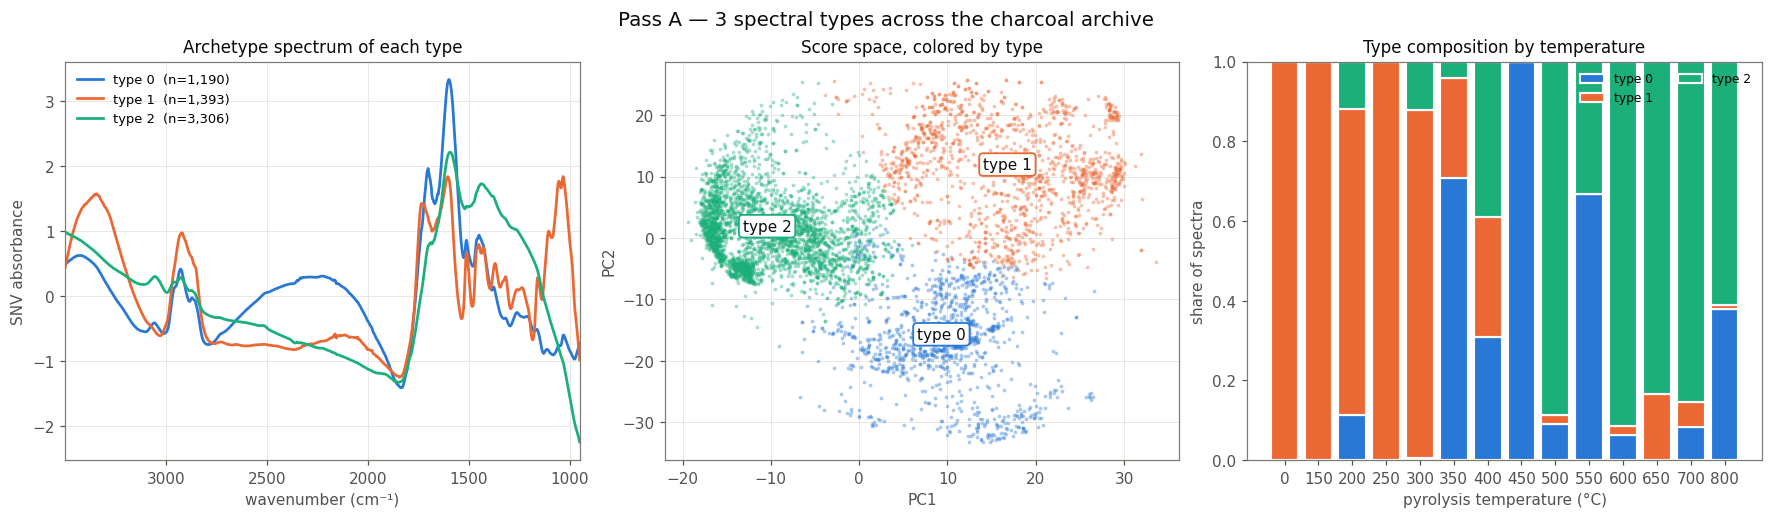

In [4]:
kmA = KMeans(n_clusters=kA, n_init=20, random_state=RANDOM_SEED).fit(pcsA)
metaA["cluster"] = kmA.labels_

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

ax = axes[0]
for c in range(kA):
    m = metaA["cluster"] == c
    ax.plot(GRID_A, XA[m.to_numpy()].mean(0), color=SERIES[c], lw=1.8,
            label=f"type {c}  (n={m.sum():,})")
ax.set_xlim(GRID_A.max(), GRID_A.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("SNV absorbance", color=INK2)
ax.set_title("Archetype spectrum of each type", color=INK)
ax.legend(fontsize=8.5)

ax = axes[1]
for c in range(kA):
    m = (metaA["cluster"] == c).to_numpy()
    ax.scatter(pcsA[m, 0], pcsA[m, 1], s=6, c=SERIES[c], alpha=0.4, linewidth=0)
    ax.annotate(f"type {c}", (pcsA[m, 0].mean(), pcsA[m, 1].mean()), fontsize=10,
                color=INK, ha="center",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=SERIES[c], lw=1.2))
ax.set_xlabel("PC1", color=INK2); ax.set_ylabel("PC2", color=INK2)
ax.set_title("Score space, colored by type", color=INK)

ax = axes[2]
tt = pd.crosstab(metaA["temp_c"], metaA["cluster"], normalize="index")
bottom = np.zeros(len(tt))
for c in tt.columns:
    ax.bar(tt.index.astype(int).astype(str), tt[c], bottom=bottom, color=SERIES[c],
           width=0.82, label=f"type {c}", edgecolor="white", linewidth=1.4)
    bottom += tt[c].to_numpy()
ax.set_xlabel("pyrolysis temperature (°C)", color=INK2)
ax.set_ylabel("share of spectra", color=INK2)
ax.set_title("Type composition by temperature", color=INK)
ax.legend(fontsize=8, ncol=2)
ax.grid(False)

fig.suptitle(f"Pass A — {kA} spectral types across the charcoal archive", fontsize=13,
             color=INK)
fig.savefig(PLOT_DIR / "02_passA_types.png", dpi=160, bbox_inches="tight")
plt.show()

**Companion view of the archetypes** — the same cluster assignments (fitted on the
SNV form), with each type's mean drawn in unit-area units instead, so the archetypes
read as band intensity.

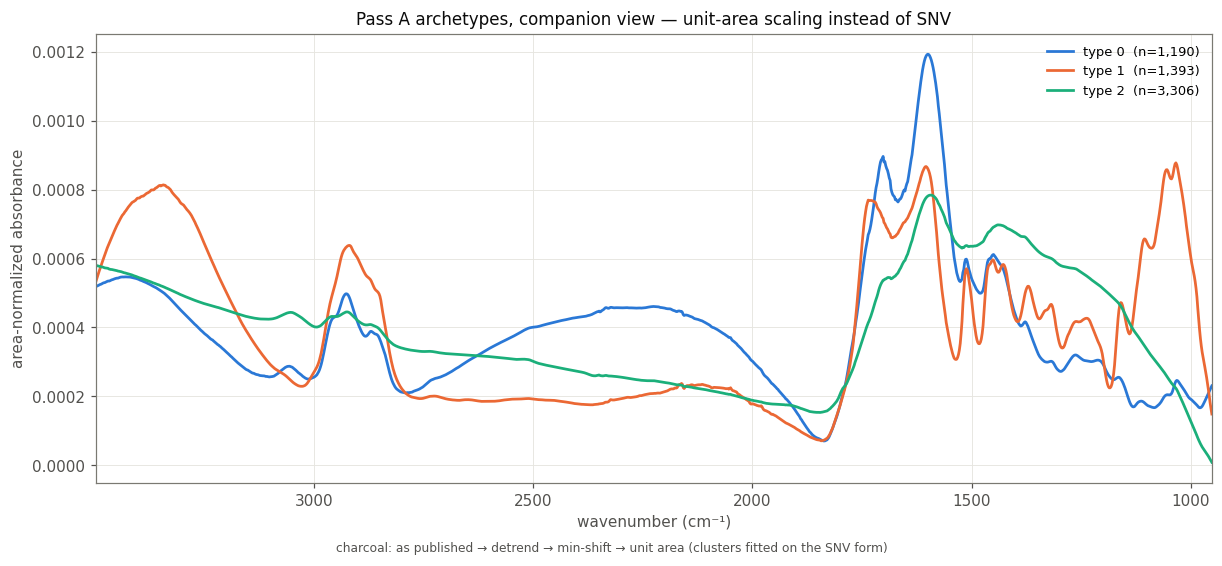

type × collection (row %):


cluster,0,1,2
source,,,
Gosling,0.10,0.35,0.55
Maezumi,0.03,0.28,0.68
McCall 6-feedstock,0.18,0.69,0.13
McCall barley,0.28,0.56,0.15
Minatre burns,0.34,0.06,0.60
Minatre ref,0.19,0.30,0.51



type × temperature (row %):


cluster,0,1,2
temp_c,,,
0.0,0.00,1.00,0.00
150.0,0.00,1.00,0.00
200.0,0.11,0.77,0.12
250.0,0.00,1.00,0.00
300.0,0.01,0.87,0.12
350.0,0.71,0.25,0.04
400.0,0.31,0.30,0.39
450.0,1.00,0.00,0.00
500.0,0.09,0.02,0.89



association of cluster with temperature (Cramér's V): 0.61
association of cluster with source collection        : 0.29
association of cluster with species/feedstock        : 0.37


In [5]:
fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
for c in range(kA):
    m = (metaA["cluster"] == c).to_numpy()
    ax.plot(GRID_A, XA_shape[m].mean(0), color=SERIES[c], lw=1.8,
            label=f"type {c}  (n={m.sum():,})")
ax.set_xlim(GRID_A.max(), GRID_A.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("Pass A archetypes, companion view — unit-area scaling instead of SNV",
             color=INK)
ax.legend(fontsize=8.5)
stamp(fig, "charcoal: as published → detrend → min-shift → unit area "
           "(clusters fitted on the SNV form)")
fig.savefig(PLOT_DIR / "02b_passA_types_shape.png", dpi=160, bbox_inches="tight")
plt.show()

print("type × collection (row %):")
ct_src = pd.crosstab(metaA["source"], metaA["cluster"], normalize="index").round(2)
display(ct_src)
print("\ntype × temperature (row %):")
display(tt.round(2))
ct_src.to_csv(TABLE_DIR / "passA_type_by_collection.csv")
tt.to_csv(TABLE_DIR / "passA_type_by_temperature.csv")

# Does the clustering track temperature, or collection?
def cramers_v(a, b):
    ct = pd.crosstab(a, b).to_numpy()
    chi2 = ((ct - np.outer(ct.sum(1), ct.sum(0)) / ct.sum()) ** 2
            / np.maximum(np.outer(ct.sum(1), ct.sum(0)) / ct.sum(), 1e-12)).sum()
    n, r, k = ct.sum(), *ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


lab = metaA.dropna(subset=["temp_c"])
print(f"\nassociation of cluster with temperature (Cramér's V): "
      f"{cramers_v(lab['cluster'], lab['temp_c']):.2f}")
print(f"association of cluster with source collection        : "
      f"{cramers_v(metaA['cluster'], metaA['source']):.2f}")
print(f"association of cluster with species/feedstock        : "
      f"{cramers_v(metaA['cluster'], metaA['species']):.2f}")

## Pass B — add Addis and see whether it forms its own type

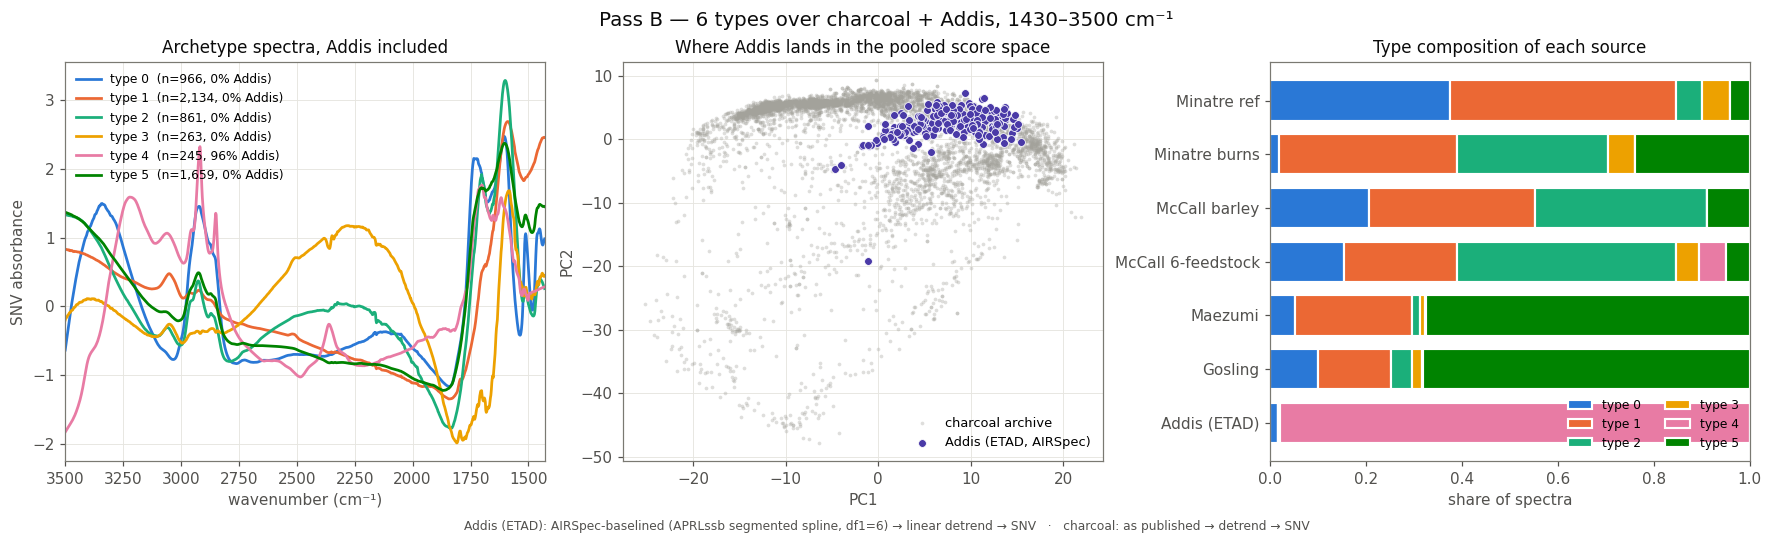

In [6]:
kmB = KMeans(n_clusters=kB, n_init=20, random_state=RANDOM_SEED).fit(pcsB)
metaB["cluster"] = kmB.labels_

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

ax = axes[0]
for c in range(kB):
    m = (metaB["cluster"] == c).to_numpy()
    share = metaB.loc[m, "is_addis"].mean()
    ax.plot(GRID_B, XB[m].mean(0), color=SERIES[c], lw=1.8,
            label=f"type {c}  (n={m.sum():,}, {share:.0%} Addis)")
ax.set_xlim(GRID_B.max(), GRID_B.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("SNV absorbance", color=INK2)
ax.set_title("Archetype spectra, Addis included", color=INK)
ax.legend(fontsize=8)

ax = axes[1]
notad = ~metaB["is_addis"].to_numpy()
ax.scatter(pcsB[notad, 0], pcsB[notad, 1], s=6, c=MUTED, alpha=0.35, linewidth=0,
           label="charcoal archive")
ax.scatter(pcsB[~notad, 0], pcsB[~notad, 1], s=26, c=ADDIS_COLOR, edgecolor="white",
           linewidth=0.5, label="Addis (ETAD, AIRSpec)", zorder=4)
ax.set_xlabel("PC1", color=INK2); ax.set_ylabel("PC2", color=INK2)
ax.set_title("Where Addis lands in the pooled score space", color=INK)
ax.legend(fontsize=8.5)

ax = axes[2]
comp = pd.crosstab(metaB["source"], metaB["cluster"], normalize="index")
bottom = np.zeros(len(comp))
for c in comp.columns:
    ax.barh(comp.index, comp[c], left=bottom, color=SERIES[c], height=0.75,
            label=f"type {c}", edgecolor="white", linewidth=1.4)
    bottom += comp[c].to_numpy()
ax.set_xlabel("share of spectra", color=INK2)
ax.set_title("Type composition of each source", color=INK)
ax.legend(fontsize=8, ncol=2)
ax.grid(False)

fig.suptitle(f"Pass B — {kB} types over charcoal + Addis, 1430–3500 cm⁻¹", fontsize=13,
             color=INK)
stamp(fig)
fig.savefig(PLOT_DIR / "03_passB_with_addis.png", dpi=160, bbox_inches="tight")
plt.show()

**Companion view of the Pass B archetypes** — same clusters, unit-area units, the
Addis side AIRSpec-baselined as everywhere in this folder.

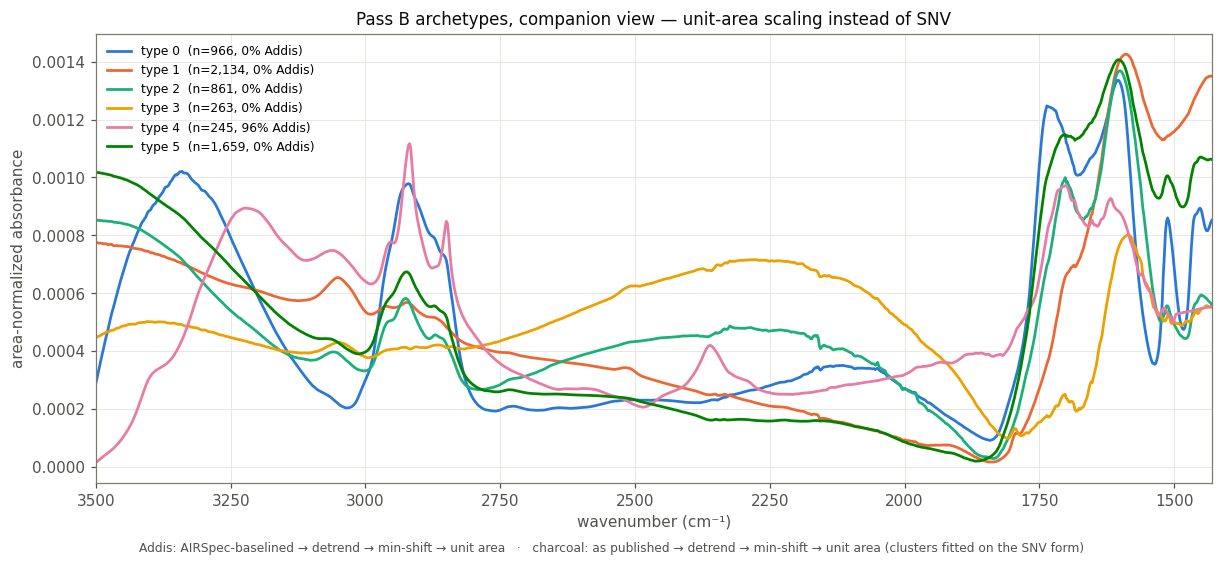

Addis filters by cluster:


,share
cluster,
4,0.979
0,0.017
3,0.004



share of each cluster that is Addis:


,Addis share
cluster,
0,0.004
1,0.000
2,0.000
3,0.004
4,0.955
5,0.000


In [7]:
fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
for c in range(kB):
    m = (metaB["cluster"] == c).to_numpy()
    share = metaB.loc[m, "is_addis"].mean()
    ax.plot(GRID_B, XB_shape[m].mean(0), color=SERIES[c], lw=1.8,
            label=f"type {c}  (n={m.sum():,}, {share:.0%} Addis)")
ax.set_xlim(GRID_B.max(), GRID_B.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("Pass B archetypes, companion view — unit-area scaling instead of SNV",
             color=INK)
ax.legend(fontsize=8)
stamp(fig, "Addis: AIRSpec-baselined → detrend → min-shift → unit area   ·   "
           "charcoal: as published → detrend → min-shift → unit area "
           "(clusters fitted on the SNV form)")
fig.savefig(PLOT_DIR / "03b_passB_shape.png", dpi=160, bbox_inches="tight")
plt.show()

addis_clusters = metaB.loc[metaB["is_addis"], "cluster"].value_counts(normalize=True)
print("Addis filters by cluster:")
display(addis_clusters.round(3).rename("share").to_frame())
purity = metaB.groupby("cluster")["is_addis"].mean()
print("\nshare of each cluster that is Addis:")
display(purity.round(3).rename("Addis share").to_frame())
comp.round(3).to_csv(TABLE_DIR / "passB_type_by_source.csv")

## A coarser view: how do the labelled groups relate to each other?

Hierarchical clustering of *group means* — one point per (collection × temperature), plus
Addis by season. Far less noisy than clustering individual spectra, and it answers the
structural question directly: does material group by how hot it got, or by which
laboratory measured it?

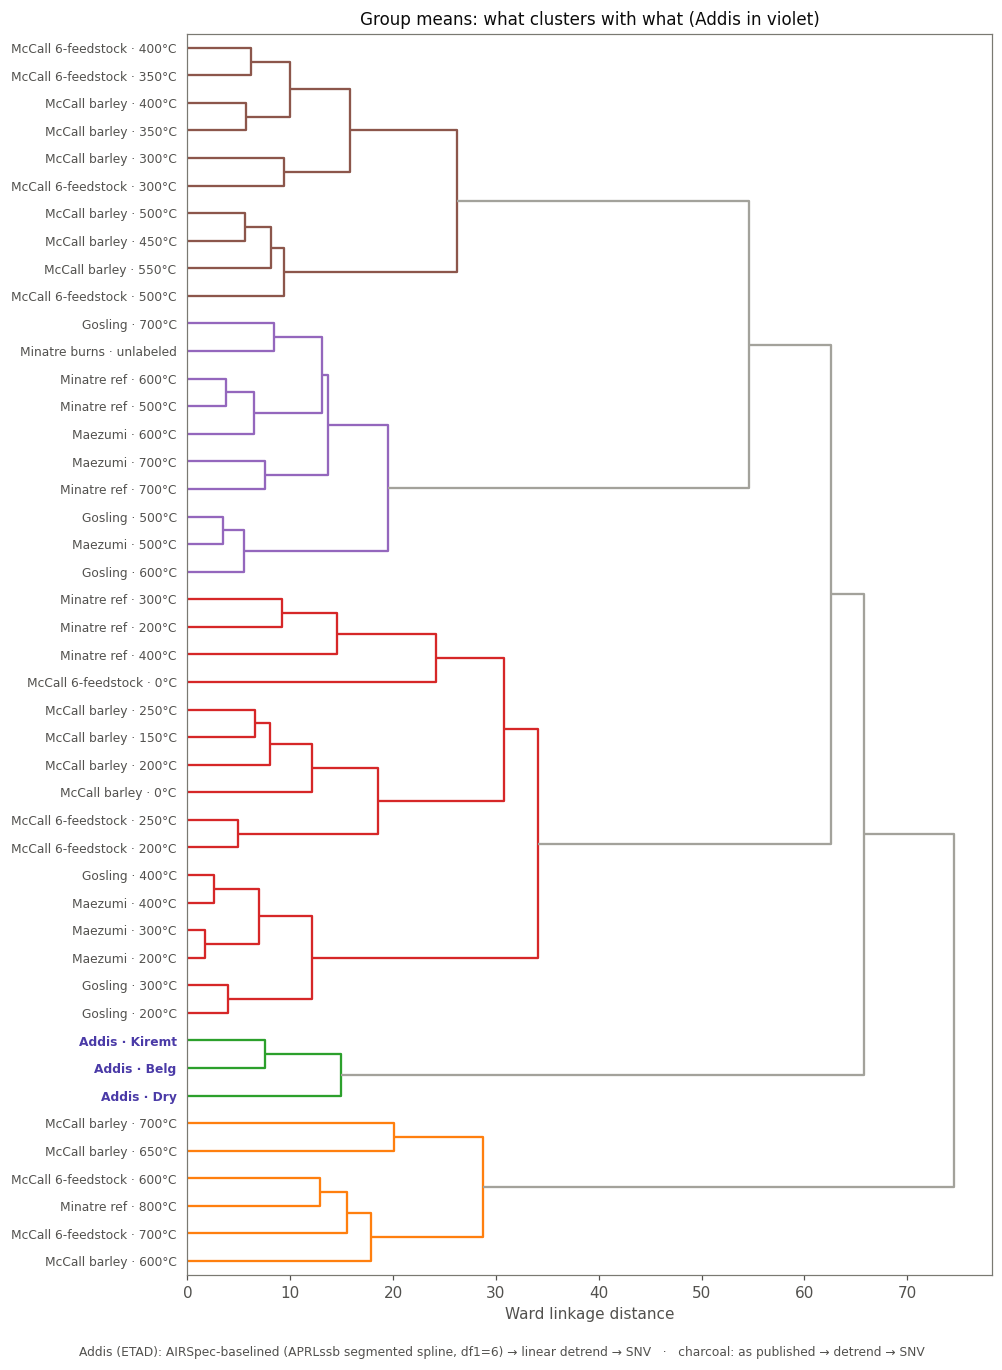

In [8]:
group_rows, group_labels = [], []
for src in metaB["source"].unique():
    m = metaB["source"] == src
    if metaB.loc[m, "is_addis"].any():
        for season in sorted(metaB.loc[m, "treatment"].dropna().unique()):
            sel = (m & (metaB["treatment"] == season)).to_numpy()
            group_rows.append(XB[sel].mean(0))
            group_labels.append(f"Addis · {season.split(' (')[0]}")
    else:
        temps = metaB.loc[m, "temp_c"].dropna().unique()
        if len(temps) == 0:
            group_rows.append(XB[m.to_numpy()].mean(0))
            group_labels.append(f"{src} · unlabeled")
        for t in sorted(temps):
            sel = (m & (metaB["temp_c"] == t)).to_numpy()
            group_rows.append(XB[sel].mean(0))
            group_labels.append(f"{src} · {t:.0f}°C")

G = np.vstack(group_rows)
Z = linkage(G, method="ward")

fig, ax = plt.subplots(figsize=(9, 12), constrained_layout=True)
dn = dendrogram(Z, labels=group_labels, orientation="right", ax=ax,
                color_threshold=0.55 * Z[:, 2].max(), above_threshold_color=MUTED)
for lbl in ax.get_ymajorticklabels():
    if lbl.get_text().startswith("Addis"):
        lbl.set_color(ADDIS_COLOR); lbl.set_fontweight("bold")
ax.set_xlabel("Ward linkage distance", color=INK2)
ax.set_title("Group means: what clusters with what (Addis in violet)", color=INK)
ax.grid(False)
stamp(fig)
fig.savefig(PLOT_DIR / "04_group_dendrogram.png", dpi=160, bbox_inches="tight")
plt.show()

pd.DataFrame({"group": group_labels}).to_csv(TABLE_DIR / "dendrogram_groups.csv",
                                             index=False)

## Takeaways

- **The archive's spectral structure is charring stage, not provenance.** With no labels
  supplied, the charcoal-only clustering settles on **3 types**, and those types line up
  with temperature: one holds essentially all material at 0–300 °C, one the 350–450 °C
  middle, one 89–91 % of everything at 500–800 °C. The association with temperature
  (Cramér's V **0.61**) is roughly double the association with the source collection
  (**0.29**) or the species (**0.37**). Six independent studies on different instruments
  are measuring the same physical axis, which is the strongest evidence yet that pooling
  them is legitimate.
- **The natural resolution is coarse and lumpy — three tiers, not a gradient.** The
  types are cleanly separated at the ends and mix badly in the middle (400 °C splits
  31/30/39 across all three). That is the same turnover `char_01` found in the
  aromatization index, arrived at independently by an algorithm with no band definitions
  in it, and it caps how finely any temperature estimate from this archive can be
  quoted.
- **Addis is its own type, and this survives correct baselining.** In the pooled pass
  **97.9 %** of Addis filters fall into a single cluster that is essentially unshared —
  under 10 charcoal spectra join them out of 5,889, and those are McCall raw feedstock.
  Addis is not a charcoal type with a different label; it is spectrally distinct
  material. This is the same conclusion `char_02` reached from correlation and distance,
  and `char_03` from the band axes, reached here without any of their assumptions.
- **Adding Addis makes the problem harder, not easier.** Pass B needs **6** clusters and
  scores a lower silhouette (0.346) than the charcoal-only pass (0.406 at k = 3), even
  though it has one extra obvious group. Restricting to 1430–3500 cm⁻¹ costs more
  structure than Addis adds — the C–O fingerprint is doing real work in Pass A.
- **The dendrogram is the figure to keep.** Group means cluster by temperature across
  collection boundaries, with the Addis seasons landing together on their own branch.
  That single picture carries the whole result: the reference material is coherent, and
  Addis is adjacent to it rather than inside it.

**Caveats.** k-means imposes spherical clusters and k is chosen by a silhouette score
that is itself only a heuristic; the type boundaries are not physical thresholds. The
library is unbalanced (Minatre contributes 2,100 of 5,889 spectra), so cluster sizes
partly reflect sampling effort. And Pass B remains blind below 1430 cm⁻¹.